In [ ]:
""" Implementation of a simple attention-based model for item recommendation. """

import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import trange


class BaseModel:
    def __init__(self,
                 n_items             : int = 8, 
                 embedding_dim       : int =  4, 
                 k_noise             : int =  8,
                 lr                  : float = 0.001,
                 epochs              : int = 30,
                 batch_size          : int = 20,
                 optimizer_name      : str = 'adam',
                 loss_type           : str = "bad",
                 min_items_basket    : int = 2,
                 n_baskets_training  : int = 400,
                 n_baskets_testing   : int = 1000,
                 proba_complementary_items : float = 0.7,
                 proba_neutral_items : float = 0.3,
                 noise_proba         : float = 0.15,
                 dict_items          : dict = None,
                 assortment          :  set = None,
                 Q                   : int =None
                 ) -> None:
        

        self.n_items       : int = n_items
        self.embedding_dim : int = embedding_dim
        self.K_noise       : int = k_noise
        self.lr            : int = lr
        self.epochs        : int = epochs
        self.batch_size    : int = batch_size

        self.optimizer_name : str = optimizer_name

        if self.optimizer_name == 'adam':
            self.optimizer = tf.keras.optimizers.Adam(self.lr)
        else:
            print(f"Optimizer {optimizer_name} not implemented, switching for default Adam")
            self.optimizer = tf.keras.optimizers.Adam(
                learning_rate=lr
            )
        self.loss_type = loss_type
        

        self.min_items_basket          : int = min_items_basket
        self.n_baskets_training        : int = n_baskets_training
        self.n_baskets_testing         : int = n_baskets_testing

        self.proba_complementary_items : float = proba_complementary_items
        self.proba_neutral_items       : float = proba_neutral_items
        self.noise_proba               : float = noise_proba
        self.dict_items                : dict = dict_items

        if self.dict_items is None:
            self.dict_items = {
                "nest0": ({0,1,2}, [-1, 1, 0, 0]) ,
                "nest1": ({3,4,5}, [1, -1, 0, 0]),
                "nest2": ({6}, [0, 0, -1, 0]),
                "nest3": ({7}, [0, 0, 0, -1])
            }

        self.assortment : set = assortment
        if self.assortment is None:
            self.assortment = {0, 1, 2, 3, 4, 5, 6, 7}
        self.available_sets = list(key for key, value in self.dict_items.items() if value[0].intersection(self.assortment))



        self.Wi    : tf.Tensor = None
        self.Wo    : tf.Tensor = None
        self.wa    : tf.Tensor = None
        self.bo    : tf.Tensor = None
        self.Theta : list = [self.Wi, self.wa, self.Wo]

        self.is_initialized : bool = False
        self.is_trained     : bool = None
        self.loss_history   : list = None

        if Q is None:
            self.Q = tf.constant([1.0/(n_items-1)]*n_items, dtype=tf.float32)
        else:
            self.Q = tf.constant(Q, dtype=tf.float32)

        if not self.is_initialized:
            self.init_model()





    def init_model(self) -> None:
        """Initializes the model parameters."""
        
        self.Wi = tf.Variable(tf.random.normal((self.embedding_dim, self.n_items), stddev=0.1), name='Wi')
        self.Wo = tf.Variable(tf.random.normal((self.n_items, self.embedding_dim), stddev=0.1), name='Wo')
        self.wa = tf.Variable(tf.random.normal((self.embedding_dim,), stddev=0.1), name='wa')
        self.bo = tf.Variable(tf.zeros((self.n_items,)), name='bo')
        self.Theta = [self.Wi, self.wa, self.Wo]
        self.is_trained = False
        self.loss_history = []
        

        
    def generate_basket(self) -> list:
        """Generates a basket of items based on the defined item sets and their relations."""

        def select_first_item() -> tuple:
            """Selects the first item and its nest randomly from the available sets."""

            chosen_nest = random.choice(self.available_sets)
            chosen_item = random.choice(list(self.dict_items[chosen_nest][0]))
            return chosen_item, chosen_nest
        
        def complete_basket(first_item : int, 
                            first_nest : str) -> set:
            """Completes the basket by adding items based on the relations of the first item."""

            basket = {first_item}
            first_key_index = int(first_nest[-1])
            for key in self.available_sets:
                nest, relations = self.dict_items[key]
                if relations[first_key_index] == 1 and random.random() < self.proba_complementary_items:
                    basket.add(random.choice(list(nest)))
                elif relations[first_key_index] == 0 and random.random() < self.proba_neutral_items:
                    basket.add(random.choice(list(nest)))
            return basket
        
        def add_noise(basket : list) -> list:
            """Adds noise items to the basket based on the defined noise probability."""
            
            noise_proba = self.noise_proba
            possible_noise = []
            for item in self.assortment:
                if item not in basket:
                    possible_noise.append(item)
            if len(possible_noise) > 0:
                for item in possible_noise:
                    if item not in basket and random.random() < noise_proba:
                        basket.add(item)
                return list(basket)
            return []

        first_chosen_item, first_chosen_nest = select_first_item()
        basket = complete_basket(first_chosen_item, first_chosen_nest)
        basket = add_noise(basket)
        
        return basket
    
    def generate_dummy_dataset(self, 
                       batch_size : int = None) -> list:
        """Generates a dataset of baskets."""

        if batch_size is None:
            batch_size = self.n_baskets_training
        
        baskets = []
        count = 0
        while count < batch_size:
            basket = self.generate_basket()
            if len(basket) >= self.min_items_basket:
                baskets.append(basket)
                count += 1
        return baskets

    def get_batches(self, 
                    dataset : list ) -> list:
        """Generates batches of baskets for training or testing."""


        indices = list(range(len(dataset)))
        random.shuffle(indices)
        for i in range(0, len(indices), self.batch_size):
            batch_indices = indices[i:i+self.batch_size]
            yield [dataset[j] for j in batch_indices]


    def context_embed(self, context_items : list) -> tf.Tensor:
        """Returns the context embedding matrix. [self.embedding_dim]"""

        context_emb = tf.gather(self.Wi, context_items, axis=1)
        attn_logits = tf.tensordot(self.wa, context_emb, axes=1)
        attn_weights = tf.nn.softmax(attn_logits)
        context_vec = tf.reduce_sum(context_emb * tf.expand_dims(attn_weights, axis=0), axis=1)
        return context_vec
        
    def score(self, 
              context_vec : tf.Tensor, 
              item : int) -> tf.Tensor:
        """Returns the score of the item given the context vector."""

        return tf.tensordot(self.Wo[item], context_vec, axes=1)
    
    def bad_loss(self, 
                 context_items : list, 
                 target_item : int) -> tf.Tensor:
        """Calculates the loss using a simple, naive softmax approach."""

        context_vec = self.context_embed(context_items)
        scores = tf.tensordot(self.Wo, context_vec, axes=1)
        return -tf.math.log(tf.nn.softmax(scores)[target_item])
    
    
    def nce_loss(self, 
                 context_items : list, 
                 target_item : int) -> tf.Tensor:
        """Calculates the loss using Noise Contrastive Estimation (NCE)."""

        context_vec = self.context_embed(context_items)
        pos_score = self.score(context_vec, target_item)
        # Negative sampling: exclude basket items
        all_items = tf.range(self.n_items, dtype=tf.int32)
        mask = ~tf.reduce_any(tf.equal(all_items[:, None], tf.expand_dims(context_items, 0)), axis=1)
        neg_pool = tf.boolean_mask(all_items, mask)
        neg_items = tf.random.shuffle(neg_pool)[:self.K_noise]
        # NCE probabilities
        KQ = self.K_noise * self.Q[target_item]
        P_1 = tf.exp(pos_score) / (tf.exp(pos_score) + KQ)
        loss = -tf.math.log(P_1 )
        for i in neg_items:
            neg_score = self.score(context_vec, i)
            KQ_neg = self.K_noise * self.Q[i]
            P_0 = 1-(tf.exp(neg_score) / (tf.exp(neg_score) + KQ_neg))
            loss -= tf.math.log(P_0 )
        return loss


    

    def train_step(self, 
                   batch : list,
                   loss_type : str = "bad") -> tf.Tensor:
        """Performs a single training step on the batch of baskets."""

        def basket_loss(basket : list) -> tf.Tensor:
            """Calculates the loss for a single basket."""

            target_item = random.choice(basket)
            context_items = [i for i in basket if i != target_item]

            if loss_type == "softmax":
                return self.bad_loss(context_items, target_item)
            elif loss_type == "nce":
                return self.nce_loss(context_items, target_item)

        with tf.GradientTape() as tape:
            total_loss = 0
            for basket in batch:
                total_loss += basket_loss(basket)


        grads = tape.gradient(total_loss, [self.Wi, self.wa, self.Wo])
        self.optimizer.apply_gradients(zip(grads, [self.Wi, self.wa, self.Wo]))
        return float(total_loss.numpy())

    def predict(self,
                context_items : list) -> np.ndarray:
        """Predicts the item probabilities given the context items."""

        context_vec = self.context_embed(context_items)
        scores = tf.tensordot(self.Wo, context_vec, axes=1)
        return tf.nn.softmax(scores).numpy()
    
    def fit(self, 
            loss_type : str = "softmax",
            batch_size : int = None,
            repr : bool = False,
            epochs : int = None
            ) -> None:
        """Trains the model for a specified number of epochs."""
        self.init_model()
        self.is_trained = True
        self.loss_type = loss_type
        if epochs == None:
            epochs = self.epochs

        
        dataset = self.generate_dummy_dataset(self.n_baskets_training)
        print(f"Generated dataset with {len(dataset)} baskets.")
        print(f"Training with batch size: {self.batch_size}, epochs: {epochs}")

        
        iterable = trange(epochs, desc="Training Epochs")
        for epoch in iterable:
            epoch_loss = 0
            for batch in self.get_batches(dataset):
                loss = self.train_step(batch, loss_type)
                epoch_loss += loss
            self.loss_history.append(epoch_loss)
            iterable.set_postfix({'epoch_loss': epoch_loss})

        print(f"Training completed. Final loss: {self.loss_history[-1]}")
        if repr:
            self.represent()

    
    
    def evaluate(self,
                 dataset : list,
                 batch_size : int = None) -> np.ndarray:
        """Evaluates the model on the provided dataset."""
        
        if not self.is_trained:
            raise ValueError("Model must be trained before evaluation. Call fit() first.")
        
        if batch_size is None:
            batch_size = self.n_baskets_testing
        
        correct_predictions = 0

        for batch in self.get_batches(dataset, batch_size):
            for basket in batch:
                target_item = random.choice(list(basket))
                context_items = [item for item in basket if item != target_item]
                scores = self.predict(context_items)
                mask = np.ones(I, dtype=bool)
                mask[context_items] = False
                scores_np = scores.numpy()
                scores_np[~mask] = -np.inf
                pred = np.argmax(scores_np)
                if pred == target_item:
                    correct_predictions += 1
        
        return correct_predictions / (len(dataset))

    def model_distribution_matrix(self) -> list:
        P = []
        for i in range(8):
            P.append(tf.nn.softmax(self.predict(np.array([i]))).numpy())
        return P
    
    def represent(self,
                  hyperparams : bool = True) -> None:
        """Prints the model parameters."""
        
        if not self.is_trained:
            raise ValueError("Model must be trained before representation. Call fit() first.")

        fig, axes = plt.subplots(1,2, figsize = (12,5))

        im1 = axes[0].imshow(np.stack(self.model_distribution_matrix()))
        axes[0].set_title("Model P(i|j) on elementary baskets")
        plt.colorbar(im1, ax = axes[0])

        im2 = axes[1].plot(self.loss_history, label='Training Loss')
        axes[1].set_xlabel('Training Steps')
        axes[1].set_ylabel('Loss')
        axes[1].set_title('Training Loss History')

        plt.tight_layout()
        plt.show()
        

        

        if hyperparams:
            print("="*30)
            print("      Model Parameters")
            print("="*30)
            print(f"{'Embedding_dim':20}: {self.embedding_dim}")
            print(f"{'K_noise':20}: {self.K_noise}")
            print(f"{'Learning_rate':20}: {self.lr}")
            print(f"{'Epochs':20}: {self.epochs}")
            print(f"{'Optimizer':20}: {self.optimizer_name}")
            print(f"{'Loss type':20}: {self.loss_type}")
            print(f"{'N_baskets_training':20}: {self.n_baskets_training}")
            print("="*30)
                

Generated dataset with 400 baskets.
Training with batch size: 20, epochs: 50


Training Epochs: 100%|██████████| 50/50 [01:09<00:00,  1.40s/it, epoch_loss=679]

Training completed. Final loss: 679.1479759216309


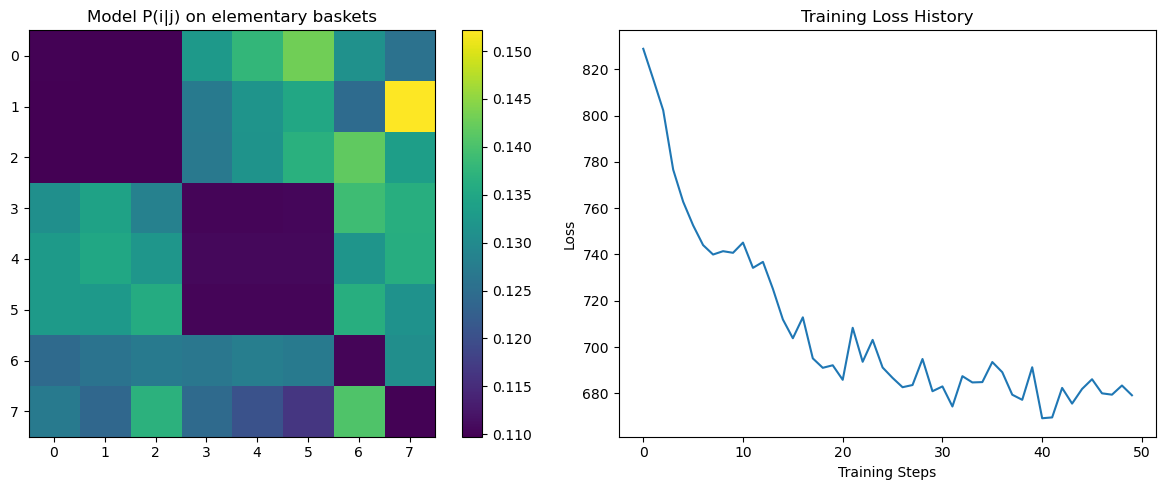

      Model Parameters
Embedding_dim       : 4
K_noise             : 8
Learning_rate       : 0.01
Epochs              : 30
Optimizer           : adam
Loss type           : softmax
N_baskets_training  : 400


In [4]:
model1 = BaseModel()
model1.fit(repr = True, epochs = 50, loss_type = "softmax", batch_size = 20)


Generated dataset with 400 baskets.
Training with batch size: 20, epochs: 100


Training Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Training Epochs: 100%|██████████| 100/100 [09:47<00:00,  5.87s/it, epoch_loss=1.09e+3]

Training completed. Final loss: 1090.6755256652832


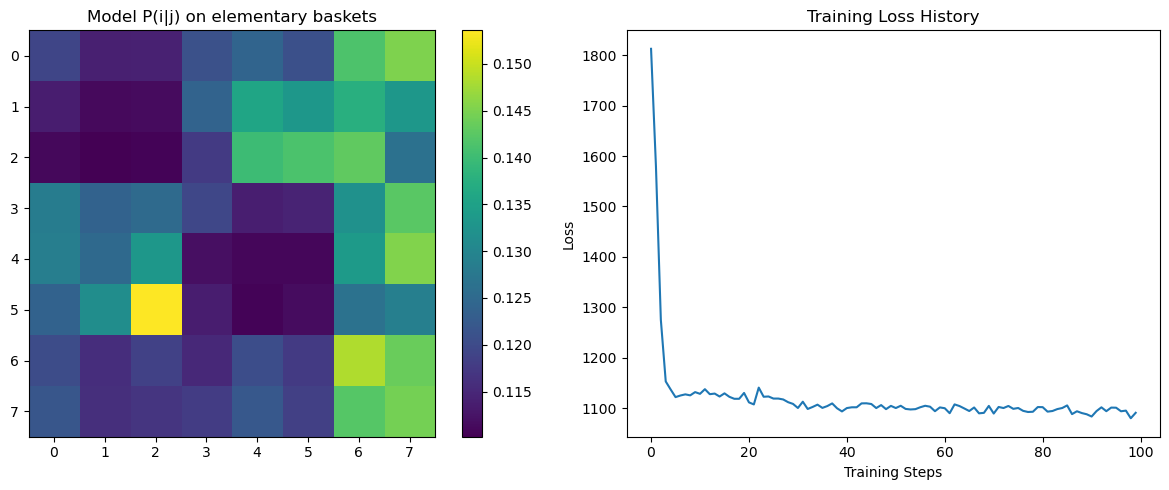

      Model Parameters
Embedding_dim       : 4
K_noise             : 8
Learning_rate       : 0.01
Epochs              : 30
Optimizer           : adam
Loss type           : nce
N_baskets_training  : 400


In [3]:
model2 = BaseModel()
model2.fit(repr = True, epochs = 100, loss_type = "nce", batch_size = 20)


2
